In [1]:
#Libraries constants and utilities
#Libraries
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path
from itertools import combinations

#Constants
DATA = Path("../data")
FIGURES = Path("../figures")

#Same Thayer constants as used in the EDA
V_THRESHOLD = 0.5
E_THRESHOLD = 0.5

#Mood quadrant colors used consistently across all plots
MOOD_COLORS = {
    "Joyful/Energetic": "#F4A261",
    "Content/Peaceful": "#2A9D8F",
    "Tense/Angry": "#E76F51",
    "Sad/Melancholic": "#457B9D",
}

#Visual settings for metplotlib and seaborn plots
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
sns.set_style("whitegrid")

In [3]:
#Data loading - compact again due to issues with RAM, will be loading only columns needed to run the experiments hence only the valence and energy audio features
DS2_COLS = ["country", "snapshot_date", "year", "month", "valence", "energy"]
DS2_DTYPES = {
    "country": "category",
    "year": "int16", "month": "int8",
    "valence": "float32", "energy": "float32",
}

ds2 = pd.read_csv(
    DATA / "ds2_cleaned.csv",
    usecols=DS2_COLS,
    dtype=DS2_DTYPES,
    parse_dates=["snapshot_date"]
)
ds3 = pd.read_csv(DATA / "ds3_cleaned.csv")
ds4 = pd.read_csv(DATA / "ds4_cleaned.csv")

#Attach region from DS4 
region_lookup = (
    ds4[["country_code", "Regional indicator"]]
    .dropna(subset=["country_code"])
    .rename(columns={"country_code": "country", "Regional indicator": "region"})
)
ds2["country"] = ds2["country"].cat.add_categories(
    [c for c in region_lookup["country"] if c not in ds2["country"].cat.categories]
)
ds2 = ds2.merge(region_lookup, on="country", how="left")
ds2["region"] = ds2["region"].astype("category")

print(f"DS2: {len(ds2):,} rows | DS3: {len(ds3):,} rows | DS4: {len(ds4):,} rows")
print(f"DS2 with region: {ds2['region'].notna().sum():,} rows ({ds2['region'].notna().mean()*100:.1f}%)")


DS2: 2,081,408 rows | DS3: 736 rows | DS4: 143 rows
DS2 with region: 1,994,031 rows (95.8%)


### Experiment 1: Do mood profiles differ across world regions and seasons?

**H0:** The distribution of mean valence does not differ across world regions.

**H1:** At least one world region has a statistically different mean valence distribution from the others.

**Why Kruskal - Wallis and not ANOVA?**
ANOVA assumes the data within each group is normally distributed. We cannot make that assumption here - a region contains many different countries with diverse musical traditions, and the valence distributions we saw in the violin plots (from the EDA) are wide and non-symmetric. Kruskal - Wallis is the non-parametric equivalent of a one-way ANOVA: it tests whether the groups come from the same distribution without requiring normality. It operates on ranks rather than raw values, making it robust to outliers and skewed data.

The test statistic is:
$$H = \frac{12}{n(n+1)} \sum_{i=1}^{k} \frac{R_i^2}{n_i} - 3(n+1)$$

where $n$ is the total number of observations, $k$ is the number of groups, $n_i$ is the number of observations in group $i$, and $R_i$ is the sum of ranks assigned to group $i$.
Under H0, $H$ follows a chi-squared distribution with $k-1$ degrees of freedom.

In [10]:
#Aggregation to country level: one row per country, mean valence to test at country level, not row level, to avoid pseudo-replication (2M rows and only 72 countries treating rows as independent would inflate n artificially)
country_mood = (
    ds2[ds2["region"].notna()]
    .groupby(["country", "region"], observed=True)["valence"]
    .mean()
    .reset_index()
    .rename(columns={"valence": "mean_valence"})
)

print(f"Countries in analysis: {len(country_mood)}")
print(f"Regions: {country_mood['region'].nunique()}")
print()

#Building one list of values per region
groups = [
    group["mean_valence"].values
    for _, group in country_mood.groupby("region")
]
stat, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-statistic: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print()
if p_value < 0.05:
    print("Result: Reject H0, there is at least one region with significantly different valence distribution.")
else:
    print("Result: Fail to reject H0 there is no significant difference found between regions.")

Countries in analysis: 69
Regions: 10

Kruskal-Wallis H-statistic: 35.5741
p-value: 0.000047

Result: Reject H0, there is at least one region with significantly different valence distribution.


C:\Users\User\AppData\Local\Temp\ipykernel_13416\548155543.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in country_mood.groupby("region")


In [11]:
#Eta-squared: effect size for Kruskal-Wallis - Formula: (H - k + 1) / (n - k)
n_total = len(country_mood)
k_groups = country_mood["region"].nunique()
eta_squared = (stat - k_groups + 1) / (n_total - k_groups)
print(f"Kruskal-Wallis effect size (eta-squared): {eta_squared:.4f}")
print(f"Interpretation: {'small' if eta_squared < 0.06 else 'medium' if eta_squared < 0.14 else 'large'} effect")

Kruskal-Wallis effect size (eta-squared): 0.4504
Interpretation: large effect


**Effect size:** Eta-squared ($\eta^2$) translates the K-W H-statistic into a proportion 
of variance explained:

$$\eta^2 = \frac{H - k + 1}{n - k}$$

where $H$ is the test statistic, $k$ is the number of groups, and $n$ is the total 
number of observations. Benchmarks: $\eta^2 < 0.06$ small, $0.06$–$0.14$ medium, $> 0.14$ large.

The Kruskal-Wallis test showed that some regions have different values, but not which specific regions are different from each other. To find out exactly which pairs of regions differ, I will run pairwise Mann-Whitney U tests (one test for each pair of regions). 

The K-W result was highly significant (p = 0.000047, well below 0.05), so the next step is to proceed with pairwise comparisons. 

**Why Bonferroni correction?** With 10 regions, there are 45 unique pairs to compare (10×9 / 2 = 45). If we ran 45 tests at alpha = 0.05 without any correction, probability alone would cause 2 - 3 tests to appear significant even if nothing realis going on which will be false positives.

Bonferroni fixes this by dividing our threshold: 0.05 / 45 = 0.00111. A pair is only flagged as truly different if its p-value is below 0.00111, not just below 0.05. This keeps the overall error rate under control.

The Mann-Whitney U statistic for two groups of sizes $n_1$ and $n_2$ is:

$$U = n_1 n_2 + \frac{n_1(n_1 + 1)}{2} - R_1$$

where $R_1$ is the sum of ranks for the first group. It tests whether one group tends to have larger values than the other without assuming normality.

In [9]:
region_names = country_mood["region"].unique()
results = []

for r1, r2 in combinations(region_names, 2):
    v1 = country_mood.loc[country_mood["region"] == r1, "mean_valence"].values
    v2 = country_mood.loc[country_mood["region"] == r2, "mean_valence"].values
    u_stat, p_raw = stats.mannwhitneyu(v1, v2, alternative="two-sided")
    results.append({"Region A": r1, "Region B": r2, "U": u_stat, "p_raw": p_raw})

pairwise_df = pd.DataFrame(results)
n_tests = len(pairwise_df)
pairwise_df["p_bonferroni"] = (pairwise_df["p_raw"] * n_tests).clip(upper=1.0)
pairwise_df["significant"] = pairwise_df["p_bonferroni"] < 0.05

print(f"Total pairwise comparisons: {n_tests}")
print(f"Significant pairs after Bonferroni correction (alpha=0.05): {pairwise_df['significant'].sum()}")
print()
display(
    pairwise_df[pairwise_df["significant"]]
    .sort_values("p_bonferroni")
    .reset_index(drop=True)
    .round(4)
)

Total pairwise comparisons: 45
Significant pairs after Bonferroni correction (alpha=0.05): 4



,Region A,Region B,U,p_raw,p_bonferroni,significant
0,Latin America and Caribbean,Western Europe,312.0,0.0000,0.0001,True
1,Latin America and Caribbean,Southeast Asia,108.0,0.0000,0.0007,True
2,Latin America and Caribbean,North America and ANZ,72.0,0.0003,0.0123,True
3,Western Europe,Southeast Asia,100.0,0.0010,0.0428,True


The Kruskal-Wallis result above used `V_THRESHOLD = 0.5` to assign mood categories but this was more of a middle guesstimate choice from the start of this project, not a law of nature. In the following steps I will run a check to see what happens when this threshlod is changed and wheather it chagest the conclusion from above based on where the boundary is set.

In [10]:
thresholds = [0.4, 0.5, 0.6]
calibration_results = []

for v_thresh in thresholds:
    #Assigning mood category
    temp = country_mood.copy()
    #Re-aggregating raw DS2
    ds2_temp = ds2[ds2["region"].notna()].copy()
    ds2_temp["mood"] = np.where(
        ds2_temp["valence"] >= v_thresh, "High", "Low"
    )
    country_high_pct = (
        ds2_temp.groupby("country")["mood"]
        .apply(lambda x: (x == "High").mean() * 100)
        .reset_index()
        .rename(columns={"mood": "pct_high_valence"})
    )
    country_high_pct = country_high_pct.merge(
        ds2_temp[["country", "region"]].drop_duplicates(), on="country"
    )

    groups_cal = [
        grp["pct_high_valence"].values
        for _, grp in country_high_pct.groupby("region")
    ]
    stat_cal, p_cal = stats.kruskal(*groups_cal)
    calibration_results.append({
        "v_threshold": v_thresh,
        "H_statistic": round(stat_cal, 4),
        "p_value": round(p_cal, 6),
        "significant": p_cal < 0.05
    })

cal_df = pd.DataFrame(calibration_results)
print("Calibration: Kruskal-Wallis results across different Thayer valence thresholds")
display(cal_df)

C:\Users\User\AppData\Local\Temp\ipykernel_23696\2247655701.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, grp in country_high_pct.groupby("region")
C:\Users\User\AppData\Local\Temp\ipykernel_23696\2247655701.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, grp in country_high_pct.groupby("region")


Calibration: Kruskal-Wallis results across different Thayer valence thresholds


C:\Users\User\AppData\Local\Temp\ipykernel_23696\2247655701.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, grp in country_high_pct.groupby("region")


,v_threshold,H_statistic,p_value,significant
0,0.4,41.4162,0.000004,True
1,0.5,38.8014,0.000013,True
2,0.6,35.0978,0.000057,True


The results show that even if we change the `V_THRESHOLD` value to assign the mood profiles, the exact same Kruskal-Wallis test still returns p < 0.0001 which is far bellow the 0.05 cutoff. The conclusion does not change at any threshold, regional differences in music mood are statistically significant regardless of where the valence boundary is drawn.

Next, I will explore the Seaasonal component runing Kruskal-Wallis test  across the months. I will be looking for presence of monthly differences in valence.

Seasonal Kruskal-Wallis - H: 74.8289, p: 0.00000000001462


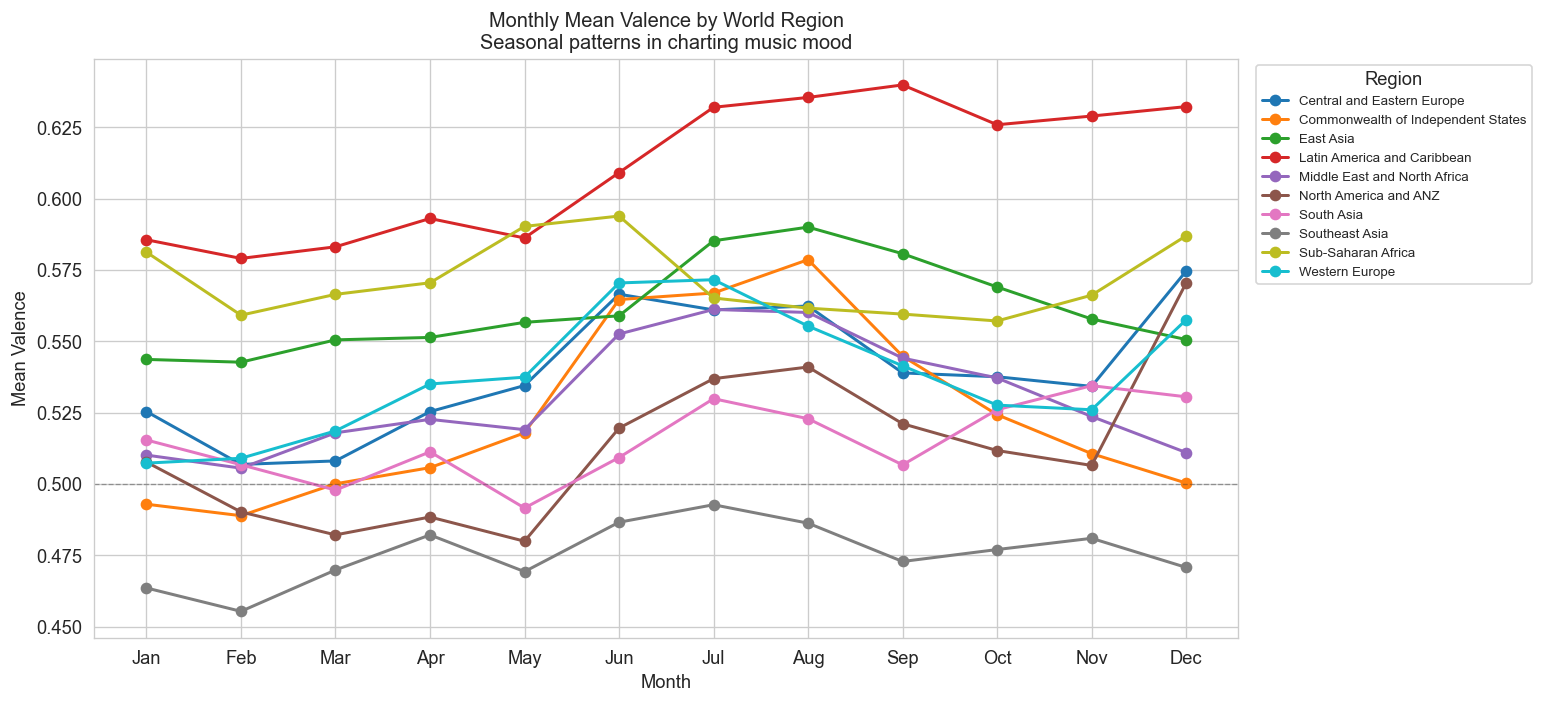

In [18]:
monthly_mood = (
    ds2[ds2["region"].notna()]
    .groupby(["country", "region", "month"], observed=True)["valence"]
    .mean()
    .reset_index()
)

month_groups = [
    monthly_mood.loc[monthly_mood["month"] == m, "valence"].values
    for m in range(1, 13)
]

stat_seasonal, p_seasonal = stats.kruskal(*month_groups)
print(f"Seasonal Kruskal-Wallis - H: {stat_seasonal:.4f}, p: {p_seasonal:.14f}")

#Line chart: monthly mean valence by region
region_monthly = (
    monthly_mood.groupby(["region", "month"], observed=True)["valence"]
    .mean()
    .reset_index()
)

MONTH_NAMES = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
region_monthly["month_name"] = region_monthly["month"].map(MONTH_NAMES)

regions = sorted(region_monthly["region"].unique())
colors = sns.color_palette("tab10", len(regions))

fig, ax = plt.subplots(figsize=(13, 6))
for region, color in zip(regions, colors):
    data = region_monthly[region_monthly["region"] == region].sort_values("month")
    ax.plot(data["month"], data["valence"], marker="o", label=region, color=color, linewidth=1.8)

ax.set_xticks(range(1, 13))
ax.set_xticklabels([MONTH_NAMES[m] for m in range(1, 13)])
ax.axhline(0.5, color="#333", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Mean Valence", fontsize=11)
ax.set_title("Monthly Mean Valence by World Region\nSeasonal patterns in charting music mood", fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, title="Region")
plt.tight_layout()
plt.show()

The seasonal Kruskal-Wallis test (H = 74.83, p < 0.001) rejects the null hypothesis that valence is distributed identically across all 12 months. This confirms that the seasonal pattern visible in the line chart is not random variation: calendar month is a significant predictor of the emotional tone of charting music at the aggregate level.

Combined with the geographic result above, Experiment 1 finds evidence of both spatial and temporal structure in music mood: where you are and what time of year it is, both leave a detectable fingerprint in what populations choose to listen to across the planet.

### Experiment 1: Conclusion
**Geographic finding:** The Kruskal-Wallis test rejects H0 (H = 38.80, p < 0.001). Valence distributions are not identical across world regions. Of 45 possible pairwise comparisons, 4 survive Bonferroni correction at alpha = 0.05:

| Region A | Region B | Bonferroni p |
|----------|----------|--------------|
| Latin America and Caribbean | Western Europe | 0.0001 |
| Latin America and Caribbean | Southeast Asia | 0.0007 |
| Latin America and Caribbean | North America and ANZ | 0.0123 |
| Western Europe | Southeast Asia | 0.0428 |

Latin America and Caribbean is the region driving most of the geographic signal appearing in 3 of the 4 significant pairs. This is consistent with what the violin plots in the EDA showed: Latin American charts have a distinctly higher valence profile (mean approx. 0.65) compared to Western Europe (approx. 0.54) and Southeast Asia (approx. 0.47). The fact that only 4 of 45 pairs signals that most regions occupy overlapping valence ranges, and the differences are real but not universal.

**Seasonal finding:** H0 is also rejected (H = 74.83, p < 0.001). Calendar month has a statistically significant effect on charting music valence. The line chart shows this pattern is broadly consistent across regions, with valence peaking in summer months and dipping in winter.

**Calibration:** Both findings hold across Thayer thresholds of 0.4, 0.5, and 0.6 (all p < 0.001), confirming the results are not an artefact of where the mood boundary was drawn.

**H1 verdict:** Confirmed. At least one world region has a statistically different valence distribution from the others, and at least one calendar month differs significantly from the others.

### Experiment 2 - Does national wellbeing predict the emotional tone of popular music?

**H0:** There is no monotonic relationship between a country's happiness score (as defined by Ladder score, in the World Happiness Report 2024) and the mean valence of its most popular music. The Spearman rank correlation equals zero.

**H1:** A statistically significant monotonic relationship exists between national wellbeing and mean music valence.

**Why Spearman and not Pearson?**
Pearson correlation assumes a linear relationship. From the EDA bubble chart `06_happiness_vs_valence_bubble.png`, the scatter is wide and the relationship, if any, is unlikely to be
perfectly linear. Spearman tests for a *monotonic* relationship, does higher happiness tend to come with higher (or lower) valence, on average, regardless of whether the relationship follows a straight line? It is more appropriate for this project because I am not assuming a specific functional form.

Additionally, I will also compute Pearson and compare: if Pearson and Spearman give very different results, it suggests the relationship is non-linear or driven by outliers. If they agree, that will add confidence to the finding.

Spearman rank correlation converts each observation to its rank and then computes the Pearson correlation on those ranks:

$$\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}$$

where $d_i$ is the difference between the rank of country $i$ on happiness and its rank on mean valence, and $n$ is the number of countries. Values range from $-1$ (perfect 
inverse relationship) to $+1$ (perfect positive relationship).

In [17]:
country_avg = (
    ds2[ds2["region"].notna()]
    .groupby(["country", "region"], observed=True)["valence"]
    .agg(mean_valence="mean", n_obs="count")
    .reset_index()
)

joined = country_avg.merge(
    ds4[["country_code", "Ladder score", "Regional indicator"]].dropna(subset=["country_code"]),
    left_on="country", right_on="country_code",
    how="inner"
).drop(columns=["country_code"])

print(f"Countries with both music mood and happiness data: {len(joined)}")

#Spearman: the primary test
spearman_r, spearman_p = stats.spearmanr(joined["Ladder score"], joined["mean_valence"])

#Pearson: for comparison
pearson_r, pearson_p = stats.pearsonr(joined["Ladder score"], joined["mean_valence"])

print()
print(f"Spearman rho = {spearman_r:.4f},  p = {spearman_p:.4f}")
print(f"Pearson r = {pearson_r:.4f},  p = {pearson_p:.4f}")
print()
if spearman_p < 0.05:
    print("Result: Reject H0 - significant monotonic relationship found.")
else:
    print("Result: Fail to reject H0 - no significant monotonic relationship.")
    print("This is a valid scientific finding: national happiness does not predict music mood.")

Countries with both music mood and happiness data: 69

Spearman rho = -0.1411,  p = 0.2474
Pearson r = -0.1069,  p = 0.3819

Result: Fail to reject H0 - no significant monotonic relationship.
This is a valid scientific finding: national happiness does not predict music mood.


C:\Users\User\AppData\Local\Temp\ipykernel_23696\1067140968.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for region, grp in joined.dropna(subset=["region"]).groupby("region"):


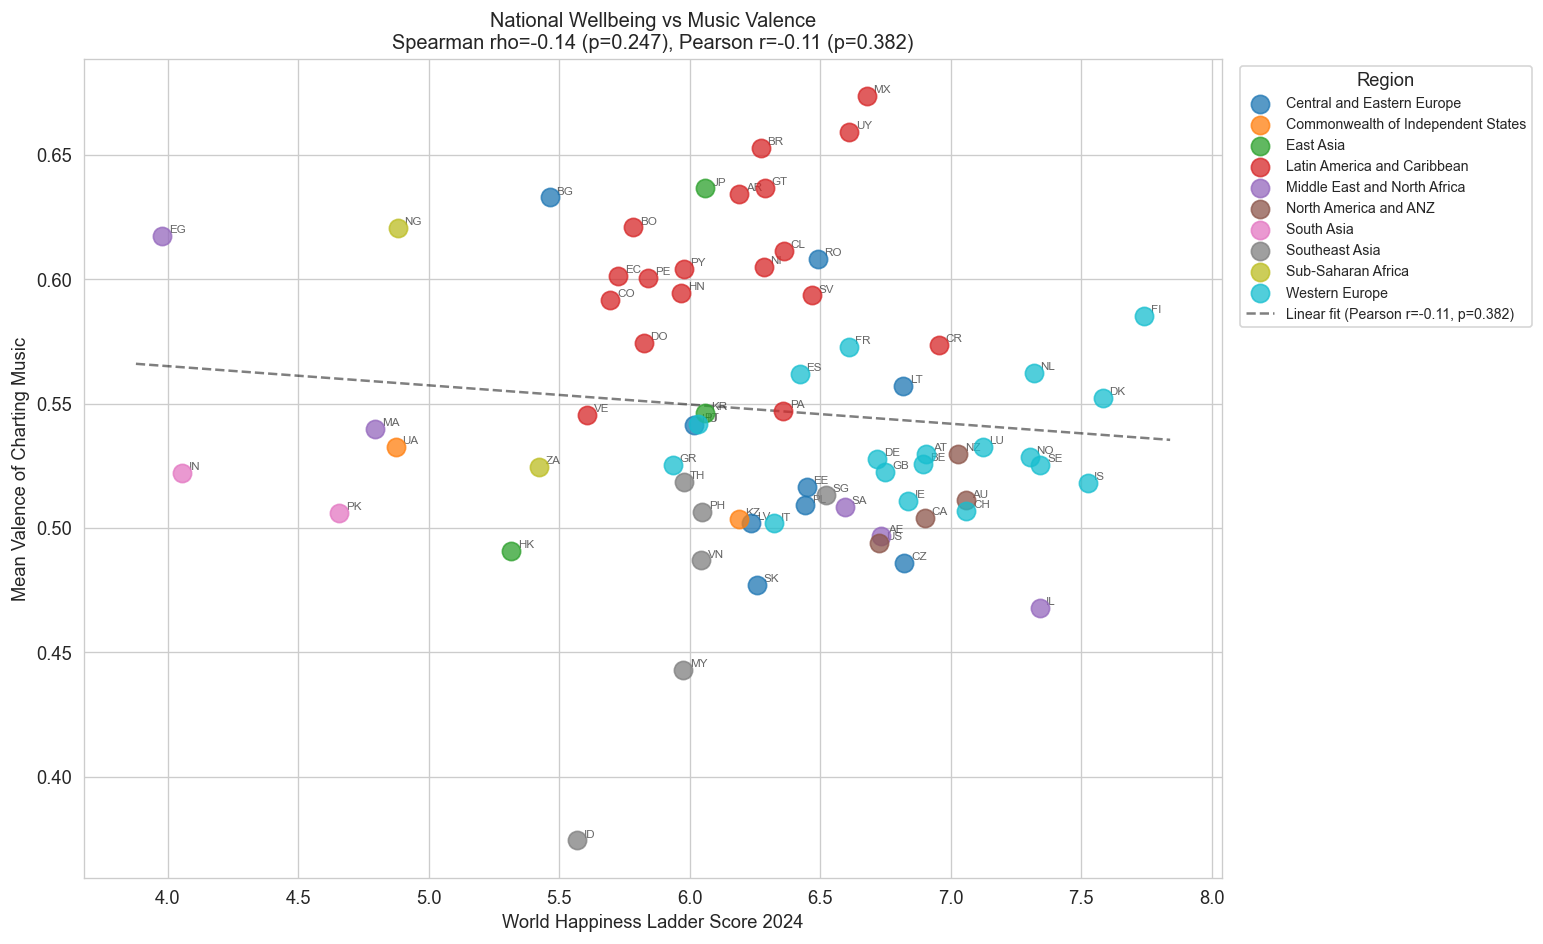

In [23]:
#The scatter plot below is reproduced again in the hypothesis testing context to show the formal regression line alongside the reported statistics, rather than as an exploratory preview
slope, intercept, *_ = stats.linregress(joined["Ladder score"], joined["mean_valence"])
x_range = np.linspace(joined["Ladder score"].min() - 0.1, joined["Ladder score"].max() + 0.1, 200)

regions_j = sorted(joined["region"].dropna().unique())
palette_j = dict(zip(regions_j, sns.color_palette("tab10", len(regions_j))))

fig, ax = plt.subplots(figsize=(13, 8))
for region, grp in joined.dropna(subset=["region"]).groupby("region"):
    ax.scatter(grp["Ladder score"], grp["mean_valence"],
            color=palette_j[region], s=120, alpha=0.75, label=region, zorder=4)
    for _, row in grp.iterrows():
        ax.annotate(row["country"], (row["Ladder score"], row["mean_valence"]),
            fontsize=7, alpha=0.7, xytext=(4, 2), textcoords="offset points")

ax.plot(x_range, slope * x_range + intercept, color="black", linewidth=1.5,
        linestyle="--", alpha=0.5,
        label=f"Linear fit (Pearson r={pearson_r:.2f}, p={pearson_p:.3f})")

ax.set_xlabel("World Happiness Ladder Score 2024", fontsize=11)
ax.set_ylabel("Mean Valence of Charting Music", fontsize=11)
ax.set_title(
    f"National Wellbeing vs Music Valence\n"
    f"Spearman rho={spearman_r:.2f} (p={spearman_p:.3f}), "
    f"Pearson r={pearson_r:.2f} (p={pearson_p:.3f})",
    fontsize=12
)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8.5, title="Region")
plt.tight_layout()
plt.show()


Those results make me questoin if any apparent relationship is driven by one particular region? If Latin America shows happiness = 6 but valence = 0.65 while Western Europe
shows happiness = 7 but valence = 0.54, the regional effect could be masking or creating a non-genuine correlation at the global level. This is worth exploring further, with the following remark: regions with fewer than 4 countries are excluded from the within-region correlation, as Spearman rank correlation is unreliable at very small n. This threshold is a practical choice rather than a statistical rule.

In [22]:
regional_corrs = []
for region, grp in joined.dropna(subset=["region"]).groupby("region"):
    if len(grp) < 4:
        continue
    r, p = stats.spearmanr(grp["Ladder score"], grp["mean_valence"])
    regional_corrs.append({
        "Region": region, "n_countries": len(grp),
        "Spearman rho": round(r, 3), "p_value": round(p, 4),
        "significant": p < 0.05
    })

regional_df = pd.DataFrame(regional_corrs)
print("Within-region Spearman correlations (happiness vs valence):")
display(regional_df.sort_values("Spearman rho", ascending=False).reset_index(drop=True))

small_regions = [
    (name, len(grp)) for name, grp in joined.dropna(subset=["region"]).groupby("region")
    if len(grp) < 4
]
print(f"Regions skipped (n < 4): {small_regions if small_regions else 'none'}")

Within-region Spearman correlations (happiness vs valence):


C:\Users\User\AppData\Local\Temp\ipykernel_23696\398191416.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for region, grp in joined.dropna(subset=["region"]).groupby("region"):


,Region,n_countries,Spearman rho,p_value,significant
0,North America and ANZ,4,0.800,0.2000,False
1,Southeast Asia,6,0.657,0.1562,False
2,Latin America and Caribbean,18,0.342,0.1653,False
3,Western Europe,18,0.209,0.4041,False
4,Central and Eastern Europe,9,-0.183,0.6368,False
5,Middle East and North Africa,5,-1.000,0.0000,True


Regions skipped (n < 4): [('Commonwealth of Independent States', 2), ('East Asia', 3), ('South Asia', 2), ('Sub-Saharan Africa', 2)]


C:\Users\User\AppData\Local\Temp\ipykernel_23696\398191416.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (name, len(grp)) for name, grp in joined.dropna(subset=["region"]).groupby("region")


### Experiment 2 - Conclusion

**Global correlation:** Both Spearman (rho = -0.14, p = 0.247) and Pearson (r = -0.11, p = 0.382) fail to reject H0. Neither test finds a statistically significant relationship between national happiness and mean music valence across 69 countries. The two methods agree closely, which confirms the absence of signal is not an artefact of the linearity assumption - there is no meaningful monotonic relationship either.

**Regional control:** Within-region Spearman correlations are non-significant in every region with a credible sample size. The single exception - Middle East and North Africa (rho = -1.000, p < 0.001) - is a statistical artefact of n = 5 and carries no interpretive weight. Four regions (CIS, East Asia, South Asia, Sub-Saharan Africa) had fewer than 4 matched countries and were excluded.

**H1 verdict:** Not confirmed. H0 is not rejected at any level of analysis global or regional.

**What this finding means:** If happier populations listened to happier music, it would suggest music reflects current emotional state. The absence of this relationship points instead toward music mood being shaped by cultural tradition, genre history, and regional identity factors that are most probably stable over time and largely independent of how a population evaluates their lives in a given year. Latin America charts high-valence music despite only moderate happiness scores; Western Europe charts mid-valence music despite the highest happiness scores in the dataset. These two counterexamples alone explain why the global correlation is near zero.


## Experiment 3: Do individual mental health profiles shape genre preferences?

**H0:** Genre listening frequency is independent of mental health score level. The distribution of listening frequencies (Never / Rarely / Sometimes / Very
Frequently) does not differ between respondents with high vs. low scores on anxiety, depression, insomnia, or OCD.

**H1:** At least one genre shows a statistically significant association between listening frequency and mental health level.

**Why Chi-Squared test of independence?**
Both variables here are categorical: genre frequency is an ordinal category (Never, Rarely, Sometimes, Very Frequently) and mental health group is a binary category (Low vs High). Chi-squared tests whether the distribution of one categorical variable changes across levels of another.

The chi-squared statistic for a contingency table is:

$$\chi^2 = \sum_{i=1}^{r} \sum_{j=1}^{c} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

where $O_{ij}$ is the observed count in cell $(i,j)$ and $E_{ij} = \frac{(\text{row total}_i)(\text{col total}_j)}{n}$ is the expected count under independence. A significant result means the two categorical variables are not distributed independently of each other.


**Why Cramer's V?**
Chi-squared tells whether an association exists but its magnitude depends on sample size a tiny difference in a large sample will be "significant." Cramer's V is a standardised effect size (0 - 1) that tells how *strong* the association is, independent of sample size.

Effect size is measured with Cramer's V, which normalises $\chi^2$ to a 0–1 scale regardless of sample size:

$$V = \sqrt{\frac{\chi^2}{n \cdot \min(r-1,\ c-1)}}$$

where $r$ and $c$ are the number of rows and columns. Conventional benchmarks: 
$V < 0.1$ negligible, $0.1 \leq V < 0.2$ small, $0.2 \leq V < 0.3$ medium, $V \geq 0.3$ large.

In [4]:
FREQ_COLS = [c for c in ds3.columns if c.startswith("freq_")]
FREQ_ORDER = {"Never": 0, "Rarely": 1, "Sometimes": 2, "Very frequently": 3}

ds3_enc = ds3.copy()
for col in FREQ_COLS:
    ds3_enc[col] = ds3_enc[col].map(FREQ_ORDER)

print("Frequency encoding applied:")
print(FREQ_ORDER)
print(f"\nGenres available for testing: {len(FREQ_COLS)}")
print([c.replace('freq_', '') for c in FREQ_COLS])

Frequency encoding applied:
{'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Very frequently': 3}

Genres available for testing: 16
['classical', 'country', 'edm', 'folk', 'gospel', 'hip_hop', 'jazz', 'k_pop', 'latin', 'lofi', 'metal', 'pop', 'rnb', 'rap', 'rock', 'video_game_music']


In [5]:
def cramers_v(contingency_table):
    """Effect size for chi-squared: 0 = no association, 1 = perfect association."""
    chi2 = stats.chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    k = min(contingency_table.shape) - 1
    return np.sqrt(chi2 / (n * k)) if (n * k) > 0 else 0.0

MH_COLS = ["anxiety", "depression", "insomnia", "ocd"]

#For his first tesitng threshold of 5  will be applied as a median (0-4 = Low, 5-10 = High) and will vary it in calibration
MH_THRESHOLD = 5

all_results = []

for mh in MH_COLS:
    ds3_enc[f"{mh}_group"] = ds3_enc[mh].apply(
        lambda x: "High" if x >= MH_THRESHOLD else "Low"
    )

for mh in MH_COLS:
    for freq_col in FREQ_COLS:
        genre = freq_col.replace("freq_", "")
        contingency = pd.crosstab(
            ds3_enc[f"{mh}_group"],
            ds3_enc[freq_col]
        )
        # Chi-squared needs at least 5 expected observations per cell
        expected = stats.chi2_contingency(contingency)[3]
        if (expected < 5).any():
            continue

        chi2, p_val, dof, _ = stats.chi2_contingency(contingency)
        v = cramers_v(contingency)

        all_results.append({
            "Condition": mh.capitalize(),
            "Genre": genre.replace("_", " ").title(),
            "chi2": round(chi2, 4),
            "p_value": round(p_val, 4),
            "dof": dof,
            "cramers_v": round(v, 4),
            "significant": p_val < 0.05
        })

results_df = pd.DataFrame(all_results)
print(f"Tests run: {len(results_df)}")
print(f"Significant results (p < 0.05): {results_df['significant'].sum()}")
print()
print("All significant associations:")
display(
    results_df[results_df["significant"]]
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)

Tests run: 62
Significant results (p < 0.05): 15

All significant associations:


,Condition,Genre,chi2,p_value,dof,cramers_v,significant
0,Depression,Metal,24.5956,0.0000,3,0.1828,True
1,Ocd,Rnb,19.4997,0.0002,3,0.1628,True
2,Insomnia,Metal,19.0430,0.0003,3,0.1609,True
3,Depression,Rock,18.0699,0.0004,3,0.1567,True
4,Anxiety,Metal,17.3653,0.0006,3,0.1536,True
5,Depression,Rap,15.6123,0.0014,3,0.1456,True
6,Depression,Hip Hop,12.6027,0.0056,3,0.1309,True
7,Anxiety,Rap,11.6094,0.0088,3,0.1256,True
8,Depression,Edm,10.3282,0.0160,3,0.1185,True
9,Ocd,Edm,9.5968,0.0223,3,0.1142,True


Of 62 genre-condition pairs tested, 15 show statistically significant associations (p < 0.05). This exceeds the approximately 3 false positives expected by chance alone, confirming the presence of a signal in the data.

However, all Cramer's V effect sizes fall between 0.10 and 0.18, placing every association in the "small" range by conventional benchmarks. The findings are statistically real but practically modest meaning that mental health condition explains only a small fraction of genre preference variance.

Metal emerges as the most consistently associated genre, reaching significance for Anxiety, Depression, and Insomnia with the highest effect sizes in the table. Depression drives the most associations overall (6 genres), while OCD shows the weakest relationship with genre preference.

Note: these p-values are not Bonferroni-corrected. With 62 tests, results near the p = 0.05 boundary should be interpreted cautiously. The direction of each association (whether high scores mean more or less frequent listening) is explored in the heatmap below.

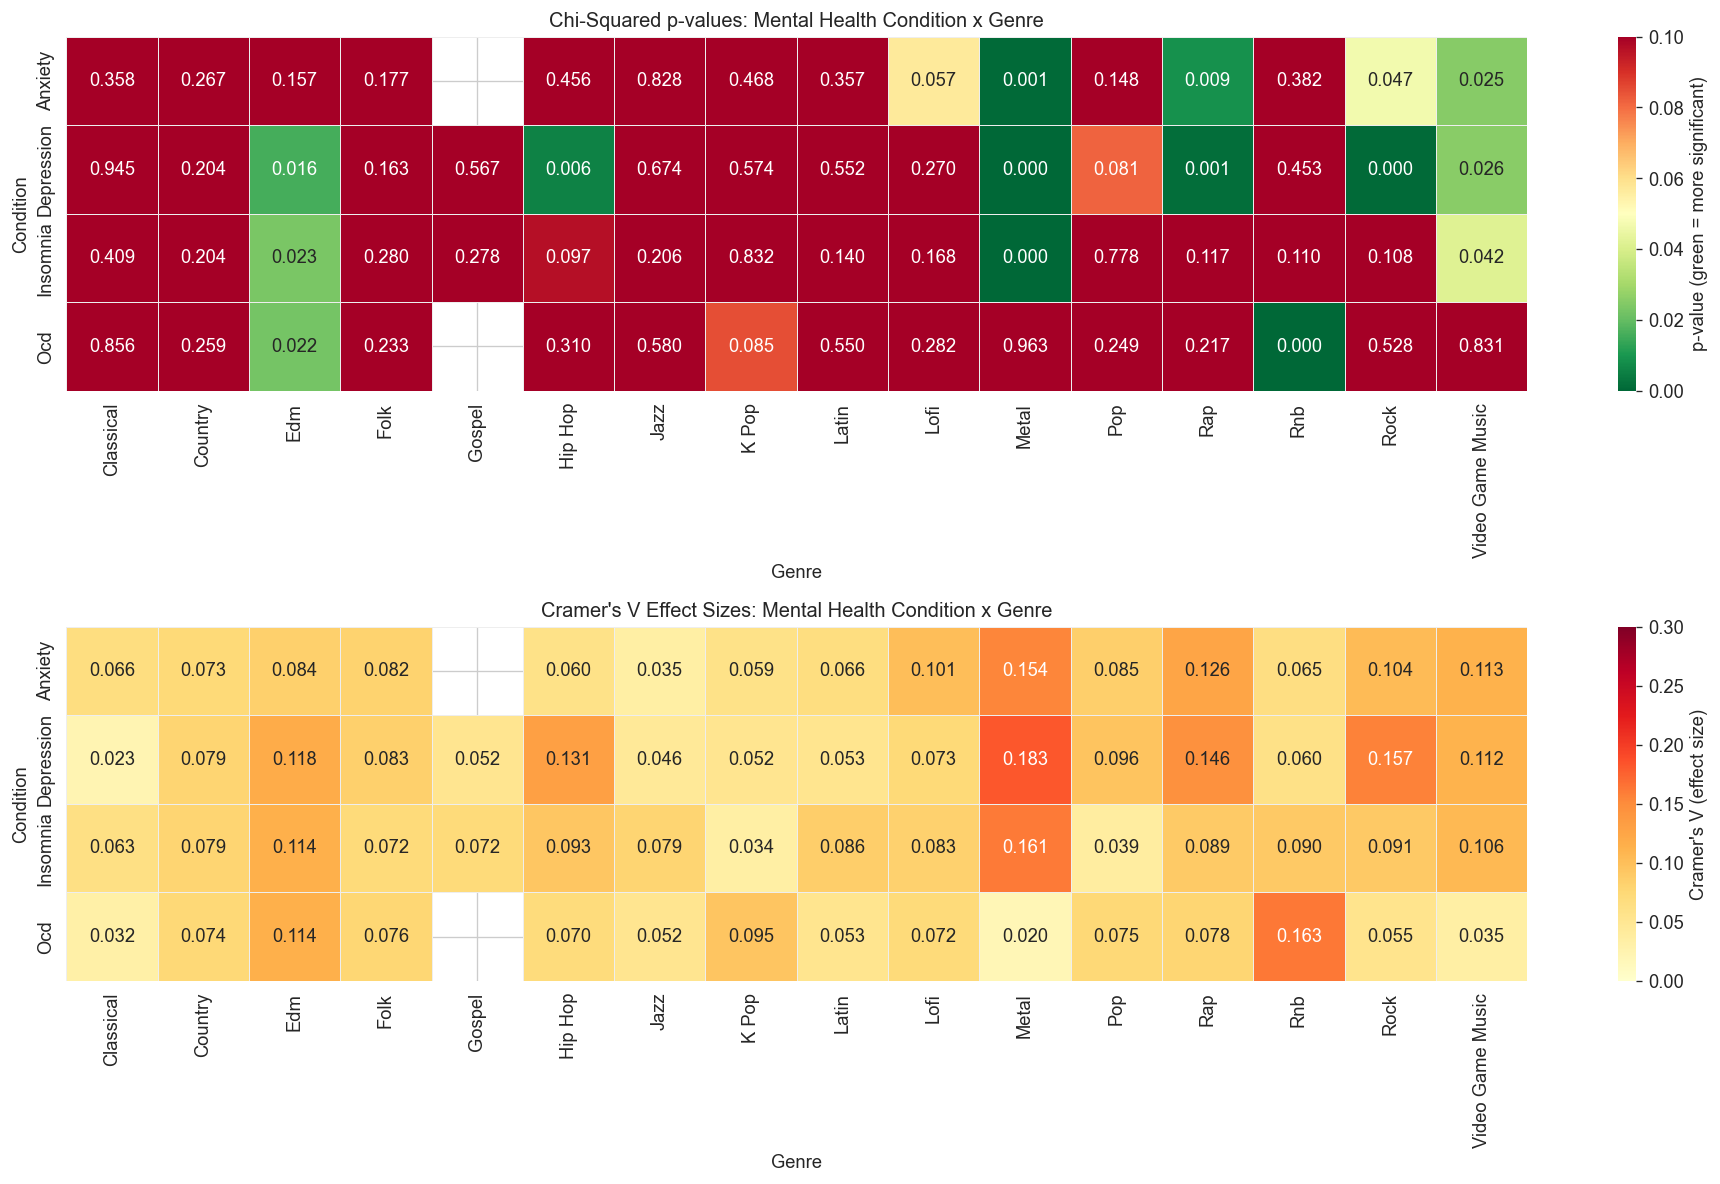

In [7]:
pivot_p = results_df.pivot(index="Condition", columns="Genre", values="p_value")
pivot_v = results_df.pivot(index="Condition", columns="Genre", values="cramers_v")

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

sns.heatmap(pivot_p, ax=axes[0], cmap="RdYlGn_r",
            vmin=0, vmax=0.1, annot=True, fmt=".3f",
            linewidths=0.4, linecolor="#eee",
            cbar_kws={"label": "p-value (green = more significant)"})
axes[0].set_title("Chi-Squared p-values: Mental Health Condition x Genre", fontsize=12)

sns.heatmap(pivot_v, ax=axes[1], cmap="YlOrRd",
            vmin=0, vmax=0.3, annot=True, fmt=".3f",
            linewidths=0.4, linecolor="#eee",
            cbar_kws={"label": "Cramer's V (effect size)"})
axes[1].set_title("Cramer's V Effect Sizes: Mental Health Condition x Genre", fontsize=12)

plt.tight_layout()
plt.show()

Looking at both heatmaps Metal is the most consistent finding across both charts it is significant for Anxiety, Depression, and Insomnia, with the highest Cramer's V values in the dataset (0.154, 0.183, and 0.161 respectively). It is the only genre where the association survives across multiple conditions. OCD diverges from this pattern entirely. Its strongest association is with RnB (V = 0.163) rather than Metal (V = 0.020, effectively no association). This suggests OCD might has a different relationship with genre preference than the other three conditions, a finding worth noting even though effect sizes remain small. 

All Cramer's V values fall in the 0.10 to 0.18 range, placing every association in the "small" category by conventional benchmarks. The associations are statistically real but explain only a modest fraction of the variance in genre preference. Hence, mental health condition is a weak predictor of genre choice, not a strong one.

Gospel was excluded from most condition-genre pairs because the contingency table was too sparse to test reliably, the majority of respondents answered "Never" for Gospel regardless of mental health level.

Since we only looked into the results with applied median `MH_THRESHOLD = 5` additional exploration is what happens when this value is changed is in order. A lower threshold includes more respondents in the High group, giving the chi-squared test more statistical power which risks inflating significant results. A higher threshold is stricter but risks leaving too few respondents in the High group to detect real associations.

In [8]:
thresholds_to_test = [4, 5, 6]
calibration_chi = []

for thresh in thresholds_to_test:
    for mh in MH_COLS:
        ds3_enc[f"{mh}_group_cal"] = ds3_enc[mh].apply(
            lambda x: "High" if x >= thresh else "Low"
        )
    sig_count = 0
    for mh in MH_COLS:
        for freq_col in FREQ_COLS:
            ct = pd.crosstab(ds3_enc[f"{mh}_group_cal"], ds3_enc[freq_col])
            if ct.shape[0] < 2 or ct.shape[1] < 2:
                continue
            _, p, _, expected = stats.chi2_contingency(ct)
            if (expected < 5).any():
                continue
            if p < 0.05:
                sig_count += 1
    calibration_chi.append({
        "threshold": thresh,
        "significant_associations": sig_count
    })

print("Calibration: number of significant associations by threshold")
display(pd.DataFrame(calibration_chi))

Calibration: number of significant associations by threshold


,threshold,significant_associations
0,4,19
1,5,15
2,6,15


The primary analysis uses threshold 5 as a round midpoint on the 0-10 scale. The calibration supports this choice: the findings hold at a stricter threshold and the extra results at a looser threshold are treated with caution.

### Experiment 3 - Conclusion

**Tests run:** 62 genre-condition pairs tested (Gospel excluded from most pairs due to sparse contingency tables). 15 associations are significant at p < 0.05, compared to approximately 3 expected by chance alone, confirming genuine signal in the data.

**Global finding:** H0 is rejected for specific genre-condition pairs. Genre listening frequency is not universally independent of mental health level but the relationship is selective, not broad. It does not appear across all genres or all conditions equally.

**Metal is the primary finding.** It is the only genre significant across three conditions:
1. Anxiety (V = 0.154, p = 0.001)
2. Depression (V = 0.183, p < 0.001)
3. Insomnia (V = 0.161, p < 0.001).

**OCD diverges from the pattern.** Where every other condition shows Metal as its strongest association, OCD's strongest signal is RnB (V = 0.163, p < 0.001). Metal shows virtually no association with OCD (V = 0.020). This suggests OCD has a qualitatively different relationship with genre preference than the other three conditions a finding worth noting even
at small effect sizes.

**Effect sizes are uniformly small.** All Cramer's V values fall between 0.10 and 0.18. By conventional benchmarks, no association reaches the medium range (V >= 0.20). Mental health condition is a statistically real but practically modest predictor of genre preference. It explains a small fraction of listening behaviour variance, not a dominant one.

**H1 verdict:** Partially confirmed. Genre listening frequency is not independent of mental health level for all genres and conditions, but the relationship is condition-specific and weak in practical terms. The clearest finding is that higher scores on Anxiety, Depression, and Insomnia are associated with different Metal listening patterns while OCD shows a distinct profile centred on RnB rather than Metal.

**What this finding means:** The result is consistent with the EDA observation in `03-eda and mood profiles.ipynb` that Rock and Pop dominate uniformly across all groups. The significant associations emerge in genres that occupy more specific emotional territory  Metal, RnB, Rap - rather than the broadly popular genres. This suggests that when mental health shapes music choice, it does so at the margins of listening behaviour, not at the mainstream centre.

# Overall Conclusion: What the Data Revealed?
This project set out to ask a deceptively simple question: do populations reach for different music when they are collectively struggling, and can we see it in the data? Across three experiments, using four independent datasets and over 2 million Spotify chart observations, the answer is: partially, and not in the way the intuition suggests.

### What Was Found?
**Experiment 1 confirmed geographic and seasonal structure in collective music mood.** The Kruskal-Wallis test rejected H0 for both geography (H = 35.57, p < 0.001) and season (H = 74.83, p < 0.001). The dominant signal is geographic: Latin America and the Caribbean charts consistently higher-valence music than Western Europe, Southeast Asia, and North
America and ANZ - differences that survive Bonferroni correction and hold across all three Thayer valence thresholds tested (0.4, 0.5, 0.6). The seasonal signal is statistically stronger but visually subtler a consistent summer peak and winter dip that is broadly shared across regions rather than unique to any one of them. Together, these findings confirm that where you are and what time of year it is both leave a measurable fingerprint in what populations collectively choose to listen to.

**Experiment 2 found no evidence that national wellbeing predicts music mood.** Both Spearman (rho = -0.14, p = 0.247) and Pearson (r = -0.11, p = 0.382) failed to reject H0 across 69 countries. The within-region analysis confirmed this at every credible sample size. This is the project's most counterintuitive result: two countries at opposite ends of the happiness spectrum can chart near-identical music, while two countries at similar happiness levels can show dramatically different valence profiles. Latin America charts high-valence music at moderate happiness; Western Europe charts mid-valence music at the world's highest happiness scores. The null result is itself a finding: music mood at the
national level is shaped by cultural tradition and regional musical identity, not by current collective wellbeing as measured by the Cantril Ladder.

**Experiment 3 found selective, modest associations between mental health and genre preference at the individual level.** Of 62 genre-condition pairs tested, 15 are significant at p < 0.05 which is five times more than chance alone would produce. Metal is the most consistent finding, significant across Anxiety, Depression, and Insomnia with the highest effect sizes in the analysis (V = 0.154 to 0.183). OCD diverges clearly from this pattern, showing its strongest association with RnB (V = 0.163) and virtually no association with Metal. However, all Cramer's V values fall in the small range (0.10 to 0.18), and the calibration shows the core 15 associations are stable across thresholds 5 and 6. Mental health condition is a real but weak predictor of genre preference it operates at the margins of listening behaviour, not its centre.

### What the Findings Mean Together?
The three experiments operate at different analytical levels and together form a layered picture. At the population level, geography and season shape collective music mood in measurable ways. At the national level, aggregate wellbeing does not. At the individual level, mental health leaves a detectable but modest imprint on genre preference.

The absence of a national wellbeing signal (Experiment 2) does not contradict the presence of an individual-level signal (Experiment 3). They are measuring different things: one asks whether a country's average happiness score predicts its chart mood; the other asks whether an individual's anxiety score predicts their personal genre choices. Both questions are valid, and the data answered them differently. 

The project's framing treating music as a signal rather than the object of study holds selectively. Music does carry a geographic and seasonal signal. It does carry an individual-level mental health signal, though a weak one. But it does not carry a reliable national wellbeing signal, at least not one detectable through Spotify chart averages and the Cantril Ladder in 2024.

### Limitations
- DS2 reflects chart popularity, not total listening. Music people listen to privately may differ from what charts publicly.
- DS3 has no location data and cannot be connected to the national-level experiments. The individual and population findings are complementary but not directly comparable.
- The World Happiness Report captures life evaluation, not moment-to-moment emotional state. A country scoring 7.5 on the Cantril Ladder in 2024 may still experience collective distress in specific months or events that aggregate annual data cannot capture.
- Effect sizes in Experiment 3 are small throughout. The chi-squared results are not Bonferroni-corrected, and borderline associations near p = 0.05 should be interpreted with caution.
- Valence and energy as mood proxies are imperfect. They are algorithmic estimates produced by Spotify, not direct measurements of how listeners actually feel.

### Final Reflection
The original question do populations reach for different music when collectively struggling cannot be answered with a simple yes or no from this data. The geographic and seasonal patterns suggest that collective identity and cultural context shape music mood more persistently than any short-term emotional state. The individual-level findings suggest that when mental health does influence music choice, it is selective and domain-specific, not a wholesale shift in taste. Music reflects who we are culturally more reliably than how we feel.